In [1]:
print("Python is working")

Python is working


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
train_df = pd.read_csv("fnn_train.csv", encoding="latin1", on_bad_lines="skip")
dev_df = pd.read_csv("fnn_dev.csv", encoding="latin1", on_bad_lines="skip")
test_df = pd.read_csv("fnn_test.csv", encoding="latin1", on_bad_lines="skip")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15212, 8)
Dev shape: (1058, 8)
Test shape: (1054, 8)


In [4]:
print(train_df.columns)
train_df.head()

Index(['id', 'date', 'speaker', 'statement', 'sources',
       'paragraph_based_content', 'fullText_based_content', 'label_fnn'],
      dtype='object')


,id,date,speaker,statement,sources,paragraph_based_content,fullText_based_content,label_fnn
0,3106,2011-01-25T06:00:00-05:00,Joe Wilkinson,A national organization says Georgia has one o...,['http://www.ajc.com/news/georgia-politics-ele...,['A coalition of government watchdog groups la...,A coalition of government watchdog groups last...,fake
1,5655,2012-04-02T11:42:20-04:00,Rick Scott,"Says Barack Obama's health care law ""will be t...",['http://www.youtube.com/watch?v=TaC0mKApf9Q&f...,['As Supreme Court justices embarked on three ...,As Supreme Court justices embarked on three da...,fake
2,3506,2011-04-01T09:49:05-04:00,J.D. Alexander,Says the Southwest Florida Water Management Di...,['http://www.tampabay.com/news/politics/gubern...,"[""Here's a new one: The Senate budget committe...",Here's a new one: The Senate budget committee ...,fake
3,3450,2011-03-21T12:20:02-04:00,Paul Ryan,"""The Congressional Budget Office has this econ...",['http://www.cnn.com/2011/POLITICS/03/17/gop.b...,"['Recently, House Budget chairman Paul Ryan, R...","Recently, House Budget chairman Paul Ryan, R-W...",real
4,4776,2011-11-13T07:30:00-05:00,Rodney Frelinghuysen,"Says the Treasury Department ""says 41 percent ...",['http://frelinghuysen.house.gov/index.cfm?sec...,['The millionairesâ tax proposal made its la...,The millionairesâ tax proposal made its late...,fake


In [5]:
train_df["label_fnn"].value_counts()

label_fnn
fake    7621
real    7591
Name: count, dtype: int64

In [6]:
def combine_text(df):
    df["combined_text"] = (
        df["statement"].astype(str) + " " +
        df["fullText_based_content"].astype(str)
    )
    return df

train_df = combine_text(train_df)
dev_df = combine_text(dev_df)
test_df = combine_text(test_df)

train_df[["statement", "fullText_based_content", "combined_text", "label_fnn"]].head()

,statement,fullText_based_content,combined_text,label_fnn
0,A national organization says Georgia has one o...,A coalition of government watchdog groups last...,A national organization says Georgia has one o...,fake
1,"Says Barack Obama's health care law ""will be t...",As Supreme Court justices embarked on three da...,"Says Barack Obama's health care law ""will be t...",fake
2,Says the Southwest Florida Water Management Di...,Here's a new one: The Senate budget committee ...,Says the Southwest Florida Water Management Di...,fake
3,"""The Congressional Budget Office has this econ...","Recently, House Budget chairman Paul Ryan, R-W...","""The Congressional Budget Office has this econ...",real
4,"Says the Treasury Department ""says 41 percent ...",The millionairesâ tax proposal made its late...,"Says the Treasury Department ""says 41 percent ...",fake


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["combined_text"].apply(clean_text)
dev_df["clean_text"] = dev_df["combined_text"].apply(clean_text)
test_df["clean_text"] = test_df["combined_text"].apply(clean_text)

train_df[["combined_text", "clean_text", "label_fnn"]].head()

,combined_text,clean_text,label_fnn
0,A national organization says Georgia has one o...,a national organization says georgia has one o...,fake
1,"Says Barack Obama's health care law ""will be t...",says barack obamas health care law will be the...,fake
2,Says the Southwest Florida Water Management Di...,says the southwest florida water management di...,fake
3,"""The Congressional Budget Office has this econ...",the congressional budget office has this econo...,real
4,"Says the Treasury Department ""says 41 percent ...",says the treasury department says percent of a...,fake


In [8]:
train_df = train_df.dropna(subset=["clean_text", "label_fnn"])
dev_df = dev_df.dropna(subset=["clean_text", "label_fnn"])
test_df = test_df.dropna(subset=["clean_text", "label_fnn"])

train_df = train_df[train_df["clean_text"].str.strip() != ""]
dev_df = dev_df[dev_df["clean_text"].str.strip() != ""]
test_df = test_df[test_df["clean_text"].str.strip() != ""]

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

Train: (15212, 10)
Dev: (1058, 10)
Test: (1054, 10)


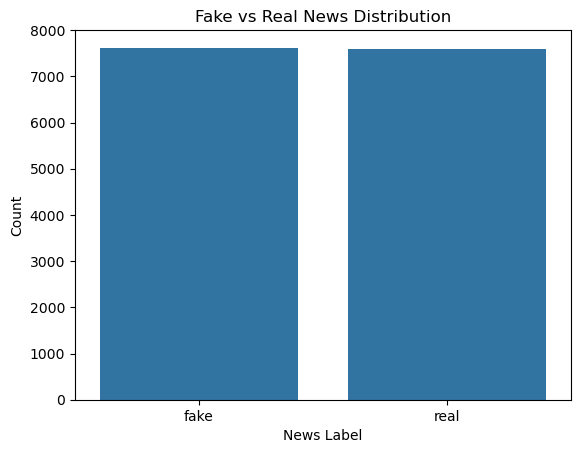

In [9]:
sns.countplot(x=train_df["label_fnn"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("News Label")
plt.ylabel("Count")
plt.show()

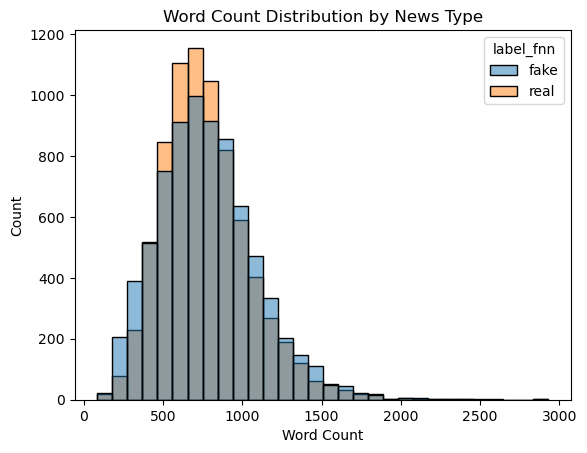

In [10]:
train_df["word_count"] = train_df["clean_text"].apply(lambda x: len(x.split()))
train_df["text_length"] = train_df["clean_text"].apply(len)

sns.histplot(data=train_df, x="word_count", hue="label_fnn", bins=30)
plt.title("Word Count Distribution by News Type")
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.show()

In [13]:
X_train = train_df["clean_text"]
y_train = train_df["label_fnn"]

X_dev = dev_df["clean_text"]
y_dev = dev_df["label_fnn"]

X_test = test_df["clean_text"]
y_test = test_df["label_fnn"]

In [12]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_dev_tfidf = tfidf.transform(X_dev)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF dev shape:", X_dev_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (15212, 10000)
TF-IDF dev shape: (1058, 10000)
TF-IDF test shape: (1054, 10000)


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    dev_pred = model.predict(X_dev_tfidf)
    
    acc = accuracy_score(y_dev, dev_pred)
    prec = precision_score(y_dev, dev_pred, average="weighted")
    rec = recall_score(y_dev, dev_pred, average="weighted")
    f1 = f1_score(y_dev, dev_pred, average="weighted")
    
    results.append([name, acc, prec, rec, f1])
    
    print("\nModel:", name)
    print("Dev Accuracy:", acc)
    print(classification_report(y_dev, dev_pred))


Model: Logistic Regression
Dev Accuracy: 0.6909262759924386
              precision    recall  f1-score   support

        fake       0.70      0.64      0.67       518
        real       0.68      0.74      0.71       540

    accuracy                           0.69      1058
   macro avg       0.69      0.69      0.69      1058
weighted avg       0.69      0.69      0.69      1058


Model: Naive Bayes
Dev Accuracy: 0.6739130434782609
              precision    recall  f1-score   support

        fake       0.68      0.64      0.66       518
        real       0.67      0.71      0.69       540

    accuracy                           0.67      1058
   macro avg       0.67      0.67      0.67      1058
weighted avg       0.67      0.67      0.67      1058


Model: Random Forest
Dev Accuracy: 0.7117202268431002
              precision    recall  f1-score   support

        fake       0.71      0.69      0.70       518
        real       0.71      0.73      0.72       540

    accuracy 

In [15]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df = results_df.sort_values(by="F1 Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.711720,0.711720,0.711720,0.711577
0,Logistic Regression,0.690926,0.691581,0.690926,0.690211
1,Naive Bayes,0.673913,0.674169,0.673913,0.673383


In [16]:
results_df.to_csv("model_results.csv", index=False)
print("model_results.csv saved successfully")

model_results.csv saved successfully


In [17]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on Dev F1 Score:", best_model_name)

if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(max_iter=1000)
elif best_model_name == "Naive Bayes":
    final_model = MultinomialNB()
else:
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)

final_model.fit(X_train_tfidf, y_train)

Best model based on Dev F1 Score: Random Forest


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
test_pred = final_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred, average="weighted")
test_recall = recall_score(y_test, test_pred, average="weighted")
test_f1 = f1_score(y_test, test_pred, average="weighted")

print("Final Model:", best_model_name)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)

print("\nClassification Report:")
print(classification_report(y_test, test_pred))

Final Model: Random Forest
Test Accuracy: 0.7960151802656547
Test Precision: 0.8640741668015101
Test Recall: 0.7960151802656547
Test F1 Score: 0.7962107384554474

Classification Report:
              precision    recall  f1-score   support

        fake       0.66      1.00      0.80       418
        real       1.00      0.66      0.80       636

    accuracy                           0.80      1054
   macro avg       0.83      0.83      0.80      1054
weighted avg       0.86      0.80      0.80      1054



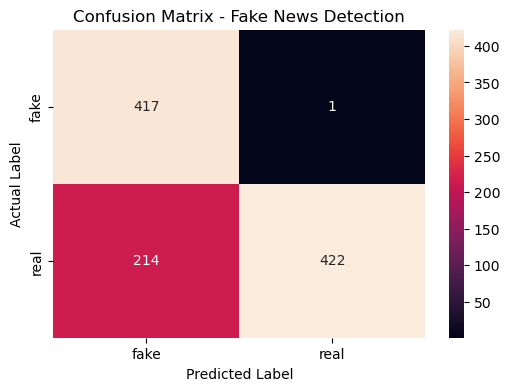

In [19]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=final_model.classes_,
    yticklabels=final_model.classes_
)

plt.title("Confusion Matrix - Fake News Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [20]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [test_accuracy, test_precision, test_recall, test_f1]
})

final_metrics.to_csv("final_metrics.csv", index=False)

final_metrics

,Metric,Score
0,Accuracy,0.796015
1,Precision,0.864074
2,Recall,0.796015
3,F1 Score,0.796211


In [21]:
prediction_output = pd.DataFrame({
    "id": test_df["id"].values,
    "statement": test_df["statement"].values,
    "Actual_Label": y_test.values,
    "Predicted_Label": test_pred
})

prediction_output["Result"] = np.where(
    prediction_output["Actual_Label"] == prediction_output["Predicted_Label"],
    "Correct",
    "Wrong"
)

prediction_output.to_csv("prediction_output.csv", index=False)

prediction_output.head()

,id,statement,Actual_Label,Predicted_Label,Result
0,1678,"""President Obama himself attempted to filibust...",real,fake,Wrong
1,1820,"In Hawaii, ""they don't have a history of throw...",real,real,Correct
2,1624,"""Our national debt ... is on track to exceed t...",real,real,Correct
3,1576,"""Health insurance companies' costs are only 4 ...",real,real,Correct
4,1770,"""We can prevent terror suspects from boarding ...",real,fake,Wrong


In [22]:
eda_output = train_df[[
    "id",
    "date",
    "speaker",
    "statement",
    "label_fnn",
    "word_count",
    "text_length"
]].copy()

eda_output.to_csv("eda_output.csv", index=False)

print("eda_output.csv saved successfully")

eda_output.csv saved successfully


In [23]:
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{label}" for label in final_model.classes_],
    columns=[f"Predicted_{label}" for label in final_model.classes_]
)

cm_df.to_csv("confusion_matrix.csv")

cm_df

,Predicted_fake,Predicted_real
Actual_fake,417,1
Actual_real,214,422


In [24]:
def predict_news(news_text):
    cleaned = clean_text(news_text)
    vectorized = tfidf.transform([cleaned])
    prediction = final_model.predict(vectorized)[0]
    
    if hasattr(final_model, "predict_proba"):
        confidence = final_model.predict_proba(vectorized).max()
    else:
        confidence = None
    
    return prediction, confidence

In [25]:
sample_news = "Government announces new education policy for students."
predict_news(sample_news)

('real', np.float64(0.88))